# Axe 3 - Satisfaction & implication

Dans ce notebook, j'étudie les variables liées aux facteurs subjectifs des employés (le ressenti et l'investissement) afin d'évaluer leur impact sur l'attrition.

Ce notebook a pour objectif :
- d'explorer les variables de l'axe,
- de comparer avec l'attrition
- d'explorer des relations internes avec les autres axe 
- de visualiser
- retenir seulement ce qui ressort clairement
---
**Remarque a moi**
Pourquoi, à conditions égales, certains partent et d’autres non ?

## 1. Exploration descriptive des variables de l’axe
---

### 1.1 Import des librairies et chargement des données
---

In [1]:
# import librairies 

import pandas as pd
import pyarrow
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display_html

In [2]:
# chargement du df
df_clean = pd.read_parquet("C:/Users/Kemu/Documents/Formation/Projet Pro Data/2_Projets_Tests/projet-RH_test/data/processed/employees_clean.parquet")
df_clean.head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7


### 1.2 Fonctions utilitaires

In [3]:
# Tableau de pourcentage variable univarié

def value_counts_percent(serie,round_n=3):

    """  Calcule la distribution (%) d'une variable catégorielle et retourne un DataFrame"""
    
    return (serie.value_counts(normalize=True).
            round(round_n).
            mul(100).
            reset_index(name="Pourcentage"))

# Tableau de pourcentage de variables bivariés
def groupby_percent(df,columns1,columns2,observed=True):
    """Calcule la distribution (%) de columns2 pour chaque modalité de columns1
    et retourne un DataFrame au format long. """
    return(df.groupby(columns1,observed=observed)[columns2].
           value_counts(normalize=True).
           round(2)
           *100).reset_index(name="Pourcentage")

# Tableau de moyenne de variable bivariés
def groupby_mean(df, columns1, columns2, observed=True) :
    """Calcul la moyenne de distribution de columns2 pour chaque modalité de columns1
    et retourne un dataFrame """
    return(df.groupby(columns1, observed=True)[columns2].mean().round(2).reset_index(name="Moyenne"))

# Table pivot en pourcentage de variables bivarié
def pivot_percent(df,index,columns):
    """ Crée un tableau pivot (%) : lignes=index, colonnes=columns."""
    df = groupby_percent(df,index,columns)
    return(df.pivot(index=index, columns=columns,values="Pourcentage").fillna(0))




### 1.3 Creation du DataFrame satisfaction_implication
---
#### Colonnes incluses dans l'axe "Satisfaction et implication"

Cet axe regroupe les caractéristiques du ressenti et de l'investissement des employés dans la structure:
- JobInvolvement 
- EnvironmentSatisfaction 
- JobSatisfaction 
- PerformanceRating 
- RelationshipSatisfaction
- WorkLifeBalance 


In [4]:
# colonnes condition de travail
cols_satisfaction_implication = ['JobInvolvement', 'EnvironmentSatisfaction','JobSatisfaction',"PerformanceRating",'RelationshipSatisfaction','WorkLifeBalance']

# creation df_condition_Trav
df_satisfaction_implication = df_clean[cols_satisfaction_implication + ['Attrition']].copy()
df_satisfaction_implication.head(3)

,JobInvolvement,EnvironmentSatisfaction,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance,Attrition
0,3,2,4,3,1,1,Yes
1,2,3,2,4,4,3,No
2,2,4,3,3,2,3,Yes


#### 1.3.1 Préparation des variables
---
- Création de variables explicites (labels) et Harmonisation des échelles ordinales
- Ordonné les échelles catégorielle
- Transformation des variables binaires

##### Renommage des codage et échelle des variables
---

Toutes les variables de cet axe sont codées sur une échelle ordinale de 1 à 4.  
Une valeur plus élevée correspond systématiquement à une perception ou une évaluation plus positive, bien que les libellés diffèrent légèrement selon la variable.

#### Variables de satisfaction (environnement, relations, travail)

- **EnvironmentSatisfaction**  
  - 1 : Faible satisfaction  
  - 2 : Satisfaction moyenne  
  - 3 : Satisfaction élevée  
  - 4 : Satisfaction très élevée  

- **JobSatisfaction**  
  - 1 : Faible satisfaction au travail  
  - 2 : Satisfaction moyenne  
  - 3 : Satisfaction élevée  
  - 4 : Satisfaction très élevée  

- **RelationshipSatisfaction**  
  - 1 : Faible satisfaction des relations professionnelles  
  - 2 : Satisfaction moyenne  
  - 3 : Satisfaction élevée  
  - 4 : Satisfaction très élevée  

- **WorkLifeBalance**  
  - 1 : Équilibre vie professionnelle / personnelle insatisfaisant  
  - 2 : Équilibre satisfaisant  
  - 3 : Bon équilibre  
  - 4 : Excellent équilibre  

#### Variables d’engagement et de performance

- **JobInvolvement**  
  - 1 : Faible engagement professionnel  
  - 2 : Engagement modéré  
  - 3 : Engagement élevé  
  - 4 : Engagement très élevé  

- **PerformanceRating**  
  - 1 : Performance faible  
  - 2 : Bonne performance  
  - 3 : Excellente performance  
  - 4 : Performance exceptionnelle  

**Remarque** : *PerformanceRating* mesure un résultat observable et ne doit pas être assimilée directement à la satisfaction ou à la motivation.

In [5]:
# Satisfaction_label

satifaction_label = {1 : "Faible",
                    2 :  "Moyenne",
                    3 : "Élevée",
                    4 : "Trés élevée"}

df_satisfaction_implication[["EnvironmentSatisfaction_label","JobSatisfaction_label","RelationshipSatisfaction_label"]] = df_satisfaction_implication[["EnvironmentSatisfaction","JobSatisfaction","RelationshipSatisfaction"]].replace(satifaction_label)

# worklifebalance
worklife_label =   {1: "Insatisfaisant",
                    2: "Satisfaisant",
                    3: "Bon",
                    4: "Excellent"}


df_satisfaction_implication["WorkLifeBalance_label"] = df_satisfaction_implication["WorkLifeBalance"].replace(worklife_label)

# engagement_label

JobInvolvement_label =  {1 : "Faible",
                        2 :  "Modéré",
                        3 : "Élevé",
                        4 : "Trés élevé"}

df_satisfaction_implication["JobInvolvement_label"] = df_satisfaction_implication["JobInvolvement"].replace(JobInvolvement_label)

# PerformanceRating

PerformanceRating_label =  {1 : "Faible",
                            2 : "Bonne",
                            3 : "Excellente",
                            4 : "Exceptionnelle"}
df_satisfaction_implication["PerformanceRating_label"] = df_satisfaction_implication["PerformanceRating"].replace(PerformanceRating_label)

df_satisfaction_implication.head()

,JobInvolvement,EnvironmentSatisfaction,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance,Attrition,EnvironmentSatisfaction_label,JobSatisfaction_label,RelationshipSatisfaction_label,WorkLifeBalance_label,JobInvolvement_label,PerformanceRating_label
0,3,2,4,3,1,1,Yes,Moyenne,Trés élevée,Faible,Insatisfaisant,Élevé,Excellente
1,2,3,2,4,4,3,No,Élevée,Moyenne,Trés élevée,Bon,Modéré,Exceptionnelle
2,2,4,3,3,2,3,Yes,Trés élevée,Élevée,Moyenne,Bon,Modéré,Excellente
3,3,4,3,3,3,3,No,Trés élevée,Élevée,Élevée,Bon,Élevé,Excellente
4,3,1,2,3,4,3,No,Faible,Moyenne,Trés élevée,Bon,Élevé,Excellente


##### Transformation de l'attrition en variable numérique

La variable *Attrition*, initialement codée sous forme catégorielle ("Yes"/"No"), a été transformée en variable numérique binaire (1/0) afin de faciliter les analyses quantitatives et le calcul de taux moyens.

In [6]:

# Transformation de la variable Attrition
df_satisfaction_implication["Attrition_num"] = df_satisfaction_implication["Attrition"].map({"No": 0, "Yes": 1})
df_satisfaction_implication.head(2)

,JobInvolvement,EnvironmentSatisfaction,JobSatisfaction,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance,Attrition,EnvironmentSatisfaction_label,JobSatisfaction_label,RelationshipSatisfaction_label,WorkLifeBalance_label,JobInvolvement_label,PerformanceRating_label,Attrition_num
0,3,2,4,3,1,1,Yes,Moyenne,Trés élevée,Faible,Insatisfaisant,Élevé,Excellente,1
1,2,3,2,4,4,3,No,Élevée,Moyenne,Trés élevée,Bon,Modéré,Exceptionnelle,0


##### Ordonné les colonnes catégorielles 



In [7]:
# Nettoyer
df_satisfaction_implication["JobSatisfaction_label"] = (df_satisfaction_implication["JobSatisfaction_label"].astype(str).str.strip().replace({"Trés élevée": "Très élevée"}))
df_satisfaction_implication["WorkLifeBalance_label"] = (df_satisfaction_implication["WorkLifeBalance_label"].astype(str).str.strip())
df_satisfaction_implication["JobInvolvement_label"] = (df_satisfaction_implication["JobInvolvement_label"].astype(str).str.strip().replace({"Trés élevé": "Très élevé"}))

# ordre
ordre_satisfaction = ["Faible", "Moyenne", "Élevée", "Très élevée"]
ordre_equilibre = ["Insatisfaisant","Satisfaisant", "Bon", "Excellent"]
ordre_jobInvolvement = ["Faible", "Modéré", "Élevé", "Très élevé"]

# Convertir 
df_satisfaction_implication["JobSatisfaction_label"] = pd.Categorical(df_satisfaction_implication["JobSatisfaction_label"],
                                                                      categories=ordre_satisfaction,
                                                                      ordered=True)

df_satisfaction_implication["WorkLifeBalance_label"] = pd.Categorical(df_satisfaction_implication["WorkLifeBalance_label"],
                                                              categories=ordre_equilibre,
                                                              ordered=True)

df_satisfaction_implication["JobInvolvement_label"] = pd.Categorical(df_satisfaction_implication["JobInvolvement_label"],
                                                              categories=ordre_jobInvolvement,
                                                              ordered=True)




#### 1.3.2 Sauvegarde du DataFrame
---

In [ ]:
df_satisfaction_implication.to_parquet(
    "C:/Users/Kemu/Documents/Formation/Projet Pro Data/2_Projets_Tests/projet-RH_test/data/processed/df_satisfaction_implication.parquet",
    index=False)

### 1.4  Analyse individuelle des variables 
---
Dans cette section, l’analyse porte sur plusieurs caractéristiques de la satisfaction et de l'implication des employés, afin de mieux comprendre le contexte organisationnel de la population étudiée.

Les variables sont analysées selon deux sous-thèmes :
- la satisfaction :  perception et ressenti (environnement, relations, équilibre)
- l'implication : comportement et investissement

Certaines variables seront analysées de manière plus approfondie que d’autres.
Cette analyse repose sur une approche **descriptive**, basée sur l’étude des **distributions**, à l’aide de **tableaux de proportions** et de **visualisations graphiques**.

Pour compléter l’analyse catégorielle, une moyenne des scores de satisfaction et d’implication est calculée comme indicateur synthétique.


#### 1.4.1 La satisfaction
---
Dans cette section, **la satisfaction au travail** est analysée à travers plusieurs dimensions complémentaires : l’environnement de travail, le poste occupé, les relations professionnelles et l’équilibre entre vie professionnelle et vie personnelle.

Les variables étudiées sont les suivantes :

- **EnvironmentSatisfaction** : niveau de satisfaction vis-à-vis de l’environnement et des conditions de travail  
- **JobSatisfaction** : e niveau de satisfaction des employés concernant leur poste et le travail qu’ils exercent.  
- **RelationshipSatisfaction** : niveau de satisfaction des relations professionnelles (collègues, manager)  
- **WorkLifeBalance** : niveau de satisfaction concernant l’équilibre entre vie professionnelle et vie personnelle


Dans le cadre de cette analyse :
- **EnvironmentSatifaction** et **RelationshipSatisfaction** feront l’objet d’une analyse descriptive légère.
-  **JobSatisfaction** et **WorkLifeBalance** seront analysées de manière plus détaillée.


Les variables de ce sous-thème sont décrites à travers leurs répartitions afin de mieux comprendre la structure des postes au sein de l’entreprise.

##### 1.4.1.1 Le niveau de satisfaction vis-à-vis de l’environnement et des conditions de travail 

##### Tableau des proportions

In [9]:
environmentSatisfaction_count = value_counts_percent(df_satisfaction_implication["EnvironmentSatisfaction_label"])
environmentSatisfaction_count

,EnvironmentSatisfaction_label,Pourcentage
0,Élevée,30.8
1,Trés élevée,30.3
2,Moyenne,19.5
3,Faible,19.3


On observe qu'une majorité des employés environ **61 %**  déclarent un niveau de satisfaction vis à vis de l'environnement et des conditions de travail **élévée** (≈ 31 % )ou **trés élevée** (≈ 30 %).

À l’inverse, les niveaux les moins représentés sont les niveaux de satisfaction **faible** (≈ 20%) et **moyenne** (≈ 19%).

Cette exploration met en évidence les grandes lignes d'un élément contextuel de la satifaction au travail.

##### 1.4.1.2 Le niveau de satisfaction vis-à-vis du poste

##### Tableau des proportions

In [10]:


jobSatisfaction_count = value_counts_percent(df_satisfaction_implication["JobSatisfaction_label"])
display(jobSatisfaction_count)


display(f'La moyenne du niveau de satifaction lié au travail exercé des employés est de {df_satisfaction_implication["JobSatisfaction"].mean().round(2)} soit une satifaction qui tend vers élevé')
display(f'La mediane du niveau de satifaction lié au travail exercé des employés est de {df_satisfaction_implication["JobSatisfaction"].median().round(2)} soit une satifaction élevé')

,JobSatisfaction_label,Pourcentage
0,Très élevée,31.2
1,Élevée,30.1
2,Faible,19.7
3,Moyenne,19.0


'La moyenne du niveau de satifaction lié au travail exercé des employés est de 2.73 soit une satifaction qui tend vers élevé'

'La mediane du niveau de satifaction lié au travail exercé des employés est de 3.0 soit une satifaction élevé'

##### Répartitions des employés selon leur niveau de satisfaction liée au poste

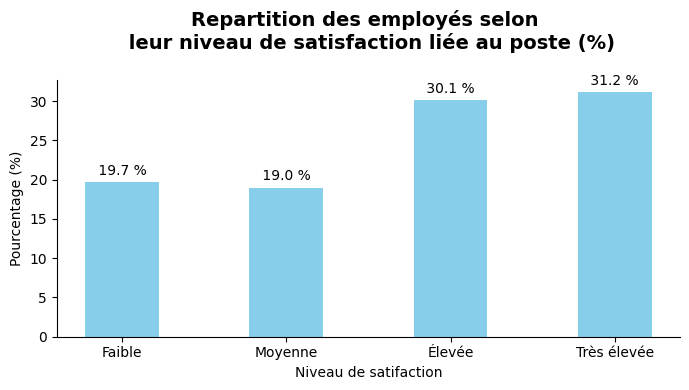

(None,)

In [11]:
# Trier
jobSatisfaction_count = jobSatisfaction_count.sort_values("JobSatisfaction_label", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(jobSatisfaction_count.index))
y = jobSatisfaction_count["Pourcentage"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .1F} % ' for v in y], padding=3)

# Axes et labels

ax.set_xticks(x)
ax.set_xticklabels(jobSatisfaction_count["JobSatisfaction_label"])

ax.set_xlabel("Niveau de satifaction")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Repartition des employés selon \n leur niveau de satisfaction liée au poste (%)\n ", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),


Ce graphique met en évidence deux niveaux de satisfaction liés au travail exercé particulièrement représentés :
- **trés élevée** (≈ 31 %)
- **élevée** (≈ 30 % )

À l’inverse, les niveaux de satisfaction **faible** et **moyen** sont moins représentés, chacun concernant environ 19 à 20 % des employés.

**Le taux moyen de satisfaction** est de **2,73**, indiquant un niveau global tendant vers une satisfaction élevée.

Cette exploration fournit une première vision du niveau de satisfaction professionnelle lié au poste occupé au sein de l’entreprise.
La majorité des salariés déclarent ainsi un niveau de satisfaction **élevé ou très élevé**, suggérant un vécu professionnel globalement favorable.

##### 1.4.1.3 Le niveau de satisfaction des relations professionnelles (collègues, manager)

##### Tableau des proportions

In [12]:
relationshipSatisfaction_count = value_counts_percent(df_satisfaction_implication["RelationshipSatisfaction_label"])
relationshipSatisfaction_count

,RelationshipSatisfaction_label,Pourcentage
0,Élevée,31.2
1,Trés élevée,29.4
2,Moyenne,20.6
3,Faible,18.8


On observe qu’une large majorité des employés déclarent un niveau de satisfaction **élevé ou très élevé** concernant leurs relations professionnelles, soit environ **62 %** de l’effectif.

À l’inverse, les niveaux de satisfaction **moyen et faible** sont moins représentés, chacun concernant environ **19 à 20 %** des employés.

##### 1.4.1.4 Le niveau de satisfaction concernant l’équilibre entre vie professionnelle et vie personnelle

##### Tableau des proportions

In [13]:
workLifeBalance_count = value_counts_percent(df_satisfaction_implication["WorkLifeBalance_label"])
display(workLifeBalance_count)


display(f"La moyenne du niveau de satifaction entre l'équilibre vie pro/perso est de {df_satisfaction_implication["WorkLifeBalance"].mean().round(2)} soit un équilibre qui tend vers un bon équilibre")
display(f"La médiane du niveau de satifaction entre l'équilibre vie pro/perso est de {df_satisfaction_implication["WorkLifeBalance"].median().round(2)} soit un bon équilibre")

,WorkLifeBalance_label,Pourcentage
0,Bon,60.7
1,Satisfaisant,23.4
2,Excellent,10.4
3,Insatisfaisant,5.4


"La moyenne du niveau de satifaction entre l'équilibre vie pro/perso est de 2.76 soit un équilibre qui tend vers un bon équilibre"

"La médiane du niveau de satifaction entre l'équilibre vie pro/perso est de 3.0 soit un bon équilibre"

##### Répartitions des employés en fonctions

Ce graphique met en évidence qu’un niveau d’équilibre entre vie professionnelle et vie personnelle est particulièrement représenté : le niveau **bon équilibre**, déclaré par environ **61 %** des employés.

À l’inverse, le niveau équilibre **insatisfaisant** apparaît comme le plus minoritaire, avec environ **5 %** des déclarations.

Cette exploration fournit une première échelle de lecture du ressenti des salariés concernant l’équilibre vie professionnelle / vie personnelle.
La majorité des salariés déclarent ainsi un équilibre satisfaisant, suggérant une perception globalement positive de cette dimension.

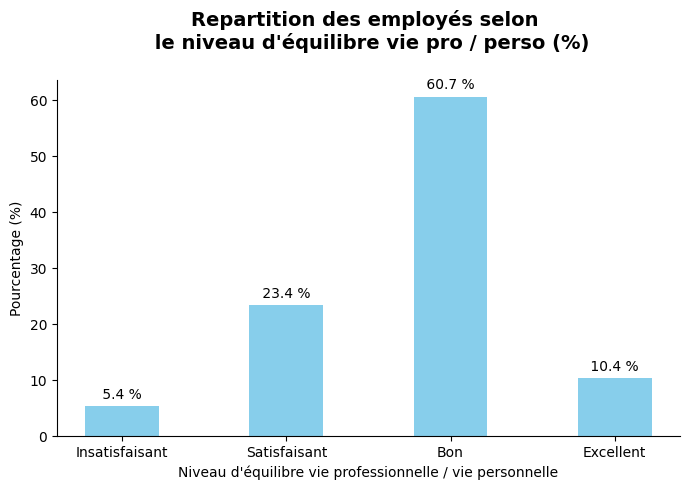

(None,)

In [14]:
# Trier
workLifeBalance_count = workLifeBalance_count.sort_values("WorkLifeBalance_label", ascending=True)

# Graphique

fig , ax = plt.subplots(figsize=(7,5))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(workLifeBalance_count.index))
y = workLifeBalance_count["Pourcentage"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .1F} % ' for v in y], padding=3)

# Axes et labels

ax.set_xticks(x)
ax.set_xticklabels(workLifeBalance_count["WorkLifeBalance_label"])

ax.set_xlabel("Niveau d'équilibre vie professionnelle / vie personnelle")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Repartition des employés selon \n le niveau d'équilibre vie pro / perso (%)\n ", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),


fig, ax = pl

**Mini-synthèse - Satisfaction**

L’analyse de la satisfaction montre qu’une large majorité des employés déclarent un niveau de satisfaction **élevé à très élevé**, aussi bien concernant leur poste, leur environnement de travail que leurs relations professionnelles.

Cette tendance se retrouve également dans l’équilibre vie professionnelle / vie personnelle, avec une majorité de salariés déclarant disposer d’un **bon équilibre**.

#### 1.4.2 Implication
---
Cette section s’intéresse aux variables liées à la **l'inplication et l'investissement** des employés.

Les variables analysées sont :

- **JobInvolvement** : niveau d’engagement professionnel de l’employé dans son travail  
- **PerformanceRating** : évaluation du niveau de performance observée  
  *(proxy indirect de l’engagement, à interpréter avec prudence)* 

L’analyse conjointe de JobInvolvement et PerformanceRating permet de distinguer l’engagement perçu par le salarié de la performance évaluée par l’entreprise.

Dans le cadre de cette analyse :
- **JobInvolvement** fera l’objet d’une analyse descriptive légère.
- **PerformanceRating***  sera analysées de manière plus détaillée.

 
Ces variables sont analysées de manière descriptive afin de caractériser la distribution des niveaux de rémunération au sein de l’entreprise.

##### 1.4.2.1 Le niveau d'engagement professionnel des employés

##### Tableau des proportions

In [15]:
jobInvolvement_count = value_counts_percent(df_satisfaction_implication["JobInvolvement_label"])
display(jobInvolvement_count)

display(f"La moyenne du niveau d'engagement des employés est de {df_satisfaction_implication["JobInvolvement"].mean().round(2)} soit une implication qui tend vers un niveau élevé")
display(f"La médiane du niveau d'engagement des employés est de {df_satisfaction_implication["JobInvolvement"].median().round(2)} soit une une implication d'un niveau élevé")

,JobInvolvement_label,Pourcentage
0,Élevé,59.0
1,Modéré,25.5
2,Très élevé,9.8
3,Faible,5.6


"La moyenne du niveau d'engagement des employés est de 2.73 soit une implication qui tend vers un niveau élevé"

"La médiane du niveau d'engagement des employés est de 3.0 soit une une implication d'un niveau élevé"

##### Répartitions des employés en fonctions de leur niveau d'engagement professionnelle.

Ce graphique met en évidence qu’un niveau d’engagement professionnel est particulièrement représenté : **environ 59 %** des employés déclarent un niveau d’engagement **élevé**.

À l’inverse, les niveaux d’engagement **faible** (≈ 6 %) et **très élevé**(≈ 10 %) sont plus minoritaires.

Le taux moyen d'engagement tend vers un niveau **élevé**, indiquant une implication professionnelle globalement importante au sein de la population étudiée.

Cette exploration fournit une première lecture de la perception qu’ont les salariés de leur propre niveau d’implication.


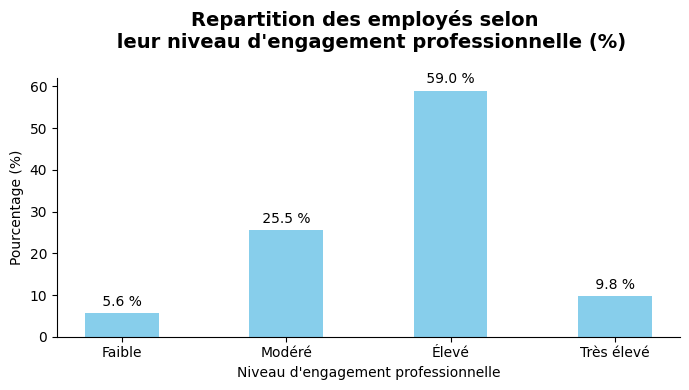

(None,)

In [16]:
# Trier
jobInvolvement_count = jobInvolvement_count.sort_values("JobInvolvement_label", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# données
x = np.arange(len(jobInvolvement_count.index))
y = jobInvolvement_count["Pourcentage"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f'{v : .1F} % ' for v in y], padding=3)

# Axes et labels

ax.set_xticks(x)
ax.set_xticklabels(jobInvolvement_count["JobInvolvement_label"])

ax.set_xlabel("Niveau d'engagement professionnelle")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Repartition des employés selon \n leur niveau d'engagement professionnelle (%)\n ", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),


##### 1.4.2.2 L'évaluation du niveau de performance observée

##### Tableau des proportions

In [17]:
performanceRating_count = value_counts_percent(df_satisfaction_implication["PerformanceRating_label"])
performanceRating_count

,PerformanceRating_label,Pourcentage
0,Excellente,84.6
1,Exceptionnelle,15.4


On observe que seuls deux niveaux d’évaluation de la performance sont représentés : **Excellente** et **Exceptionnelle**.

Le niveau **Excellente** est largement majoritaire, concernant environ **85 %** de la population.

**Mini-synthèse - implication**

L’analyse de l’implication met en évidence qu’une large majorité des employés déclarent un niveau d’engagement professionnel **élevé**.

Cette tendance est également observée dans l’évaluation de la performance, la majorité des salariés étant classée à un niveau de performance **élevé**.

Après avoir décrit les principales caractéristiques de la satification et implication des employés, cette section s’intéresse désormais à leur relation avec l’attrition.

L’objectif est d’observer si certaines dimensions subjective  telles que la satisfaction et l'implication présentent des différences de taux d’attrition selon les groupes étudiés.



## 2. Attrition - Satifcation/Implication
---

### 2.1 Introduction
---
Dans cette section, je compare la variable cible, l’attrition, aux variables des conditions de travail analysées précédemment, afin d’identifier d’éventuelles relations entre ces caractéristiques et le départ des employés.

##### Tableau de proportions Attrition Yes / No

In [18]:
attrition = df_satisfaction_implication['Attrition'].value_counts(normalize=True).sort_values(ascending=False).round(3)*100

df_attrition = attrition.reset_index()
df_attrition.columns = ['Attrition', "Pourcentage"]

df_attrition

,Attrition,Pourcentage
0,No,83.9
1,Yes,16.1


D’après ce tableau, le taux d’attrition global observé dans le jeu de données est d’environ **16 %**, ce qui constitue le niveau de référence pour les analyses suivantes.
Dans les analyses suivantes, l’accent est mis sur le taux d’attrition (Attrition = Yes), les non-départs représentant le complément à 100 %.

### 2.2 Analyse de l’attrition selon les variables de la satisfaction et l'implication
---
Dans cet partie, les sous themes précedent sont réutilisé pour analyser les variables avec l'attrition.

Certaines variables de cet axes ont été explorées individuellement mais n’ont pas été retenues dans l’analyse de l’attrition, en raison de distributions peu contrastées ou d’un intérêt analytique limité observé lors de l’exploration initiale.

L’analyse combine des distributions en pourcentage, permettant d’observer la répartition des salariés selon les niveaux de satisfaction, et des moyennes, utilisées comme indicateurs synthétiques afin de comparer les groupes selon le statut d’attrition.

Les variables sélectionnées sont comparées à partir de leur fréquence, à l’aide de tableaux de proportions et de visualisations graphiques.  
Cette approche permet d’identifier des différences de taux d’attrition entre les groupes avant toute analyse approfondie.

#### 2.2.1 Attrition et la satisfaction
---

Dans cette partie, les variables analysé avec l'attrition sont  


##### 2.2.1.1 Attrition et Le niveau de satisfaction vis-à-vis de l’environnement et des conditions de travail 
---

##### Tableaux descriptifs (Proportion ­­(%) et Moyenne)

In [19]:

# Tableau de proportion
environmentSatisfaction_attrition = df_satisfaction_implication[["EnvironmentSatisfaction_label", "Attrition"]]

## pivot : ligne = niveau de satifaction, colonne= attrition, valeur =pourcentage
pivot_environmentSatisfaction_attrition = pivot_percent(environmentSatisfaction_attrition, "EnvironmentSatisfaction_label","Attrition")


# Tableau de Moyenne
environmentSatisfaction_attrition_mean = groupby_mean(df_satisfaction_implication, "EnvironmentSatisfaction","Attrition_num")

# Tableau cote à cote

display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
        t1=pivot_environmentSatisfaction_attrition.to_html(),
        t2=environmentSatisfaction_attrition_mean.to_html()
    ),
    raw=True
)

Attrition,No,Yes
EnvironmentSatisfaction_label,,
Faible,75.0,25.0
Moyenne,85.0,15.0
Trés élevée,87.0,13.0
Élevée,86.0,14.0
,EnvironmentSatisfaction,Moyenne
0,1,0.25
1,2,0.15
2,3,0.14
3,4,0.13


On observe que les employés déclarant un niveau **faible** de satisfaction vis-à-vis de l’environnement et des conditions de travail présentent le taux d’attrition le plus élevé (**≈ 25 %**).

À l’inverse, le taux d’attrition est le plus faible pour les employés déclarant un niveau de satisfaction **très élevé** (≈ **13** %).

Cette tendance est confirmée par l’analyse des taux moyens d’attrition, qui diminuent progressivement lorsque le niveau de satisfaction augmente.

#### 2.2.1.2 Attrition et le niveau de satifaction lié au travail exercé
---

##### Tableaux descriptifs (Proportion ­­(%) et Moyenne)

In [20]:
# Tableau de proportion
jobSatisfaction_attrition = df_satisfaction_implication[["JobSatisfaction_label", "Attrition"]]

## pivot : ligne = niveau de satifaction, colonne= attrition, valeur =pourcentage
pivot_jobSatisfaction_attrition = pivot_percent(jobSatisfaction_attrition,"JobSatisfaction_label", "Attrition")


# Tableau de Moyenne
jobSatisfaction_attrition_mean = groupby_mean(df_satisfaction_implication,"JobSatisfaction", "Attrition_num")


# Tableau côte à côte

display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
        t1=pivot_jobSatisfaction_attrition.to_html(),
        t2=jobSatisfaction_attrition_mean.to_html()
    ),
    raw=True
)

Attrition,No,Yes
JobSatisfaction_label,,
Faible,77.0,23.0
Moyenne,84.0,16.0
Élevée,83.0,17.0
Très élevée,89.0,11.0
,JobSatisfaction,Moyenne
0,1,0.23
1,2,0.16
2,3,0.17
3,4,0.11


##### Graphique — Analyse de la relation entre le niveau de satisfaction vis à vis du poste et l'attrition

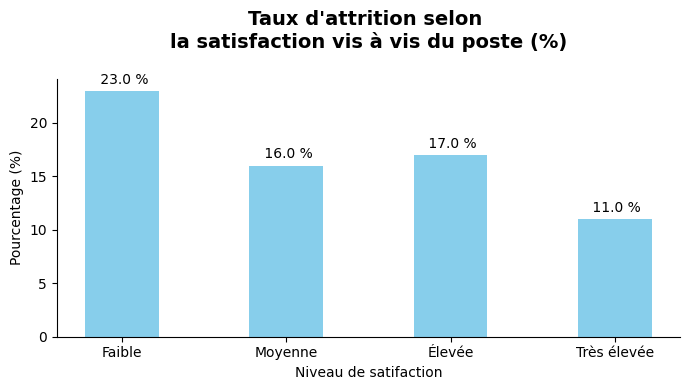

(None,)

In [21]:
pivot_jobSatisfaction_attrition = pivot_jobSatisfaction_attrition.sort_values("JobSatisfaction_label", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_jobSatisfaction_attrition.index))
y = pivot_jobSatisfaction_attrition["Yes"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_jobSatisfaction_attrition.index)

ax.set_xlabel("Niveau de satifaction")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Taux d'attrition selon \nla satisfaction vis à vis du poste (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

Ce graphique met en évidence que les employés déclarant un niveau **faible** de satisfaction vis-à-vis de leur poste présentent le taux d’attrition le plus élevé (**≈ 25 %**).

Le taux d’attrition diminue ensuite pour les niveaux de satisfaction **moyen et élevé,** avec des valeurs comprises entre **16 % et 17 %**, et atteint son niveau le plus faible chez les salariés déclarant une satisfaction **très élevée** (**≈ 11 %**).

Cette tendance est cohérente avec les taux moyens d’attrition observés et met en évidence une relation décroissante entre la satisfaction vis-à-vis du poste et l’attrition.

#### 2.2.1.3 Attrition et Le niveau de satisfaction des relations professionnelles (collègues, manager)
---

##### Tableaux descriptifs (Proportion ­­(%) et Moyenne)

In [22]:
# Tableau de proportion
relationshipSatisfaction_attrition = df_satisfaction_implication[["RelationshipSatisfaction_label", "Attrition"]]

pivot_relationshipSatisfaction_attrition = pivot_percent(relationshipSatisfaction_attrition, "RelationshipSatisfaction_label", "Attrition")

# Tableau de moyenne
relationshipSatisfaction_attrition_mean = groupby_mean(df_satisfaction_implication,"RelationshipSatisfaction", "Attrition_num")

# Tableau côte à côte

display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
        t1=pivot_relationshipSatisfaction_attrition.to_html(),
        t2=relationshipSatisfaction_attrition_mean.to_html()
    ),
    raw=True)

Attrition,No,Yes
RelationshipSatisfaction_label,,
Faible,79.0,21.0
Moyenne,85.0,15.0
Trés élevée,85.0,15.0
Élevée,85.0,15.0
,RelationshipSatisfaction,Moyenne
0,1,0.21
1,2,0.15
2,3,0.15
3,4,0.15


On observe que le taux d’attrition est plus élevé chez les employés déclarant un niveau de satisfaction **faible** dans leurs relations professionnelles (≈ **21 %**).

À l’inverse, les salariés déclarant un niveau de satisfaction **moyen, élevé ou très élevé** présentent un taux d’attrition identique, fixé à **15 %**.

Le taux moyen d’attrition observé confirme cette tendance.

#### 2.2.1.4 Attrition et le niveau de satisfaction concernant l’équilibre entre vie professionnelle et vie personnelle
---

##### Tableaux descriptifs (Proportion ­­(%) et Moyenne)

In [23]:
# Tableau de proportion
workLifeBalance_attrition = df_satisfaction_implication[["WorkLifeBalance_label", "Attrition"]]

pivot_workLifeBalance_attrition = pivot_percent(workLifeBalance_attrition,"WorkLifeBalance_label", "Attrition")

# Tableau de moyenne
workLifeBalance_attrition_mean = groupby_mean(df_satisfaction_implication,"WorkLifeBalance", "Attrition_num")

# Tableau côte à côte

display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
        t1=pivot_workLifeBalance_attrition.to_html(),
        t2=workLifeBalance_attrition_mean.to_html()
    ),
    raw=True)

Attrition,No,Yes
WorkLifeBalance_label,,
Insatisfaisant,69.0,31.0
Satisfaisant,83.0,17.0
Bon,86.0,14.0
Excellent,82.0,18.0
,WorkLifeBalance,Moyenne
0,1,0.31
1,2,0.17
2,3,0.14
3,4,0.18


##### Graphique - Relation entre Le niveau de satisfaction concernant l’équilibre entre vie professionnelle et vie personnelle et l'attrition

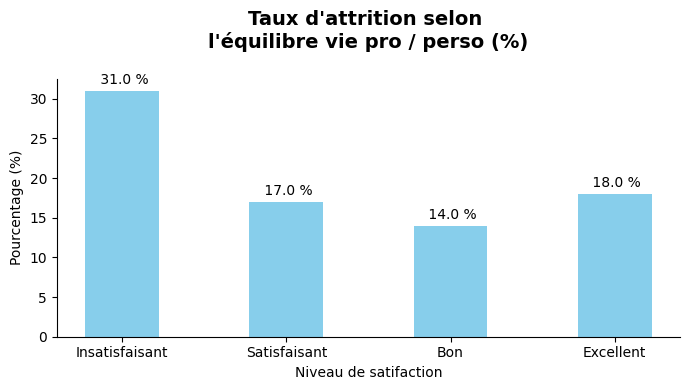

(None,)

In [24]:
pivot_workLifeBalance_attrition= pivot_workLifeBalance_attrition.sort_values("WorkLifeBalance_label", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_workLifeBalance_attrition.index))
y = pivot_workLifeBalance_attrition["Yes"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_workLifeBalance_attrition.index)

ax.set_xlabel("Niveau de satifaction")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Taux d'attrition selon \nl'équilibre vie pro / perso (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

On observe que le taux d’attrition est plus élevé chez les employés déclarant un niveau **insatisfaisant** d’équilibre entre vie professionnelle et vie personnelle (≈ **31 %)**.

Le taux d’attrition diminue pour les niveaux d’équilibre jugés **satisfaisant** (≈ 17 %) et **bon** (≈ 14 %).

En revanche, une légère remontée du taux d’attrition est observée pour les employés déclarant un niveau d’équilibre **excellent** (≈ **18 %)**.

Cette configuration est également retrouvée lorsque l’on observe les taux moyens d’attrition par niveau d’équilibre.

#### 2.2.2 Attrition et l'implication
---

Dans cette partie, les variables analysés avec l'attrition sont l'engagement et la performance observée.


#### 2.2.2.1 Attrition et Le niveau d'engagement professionnel des employés
---

##### Tableaux descriptifs (Proportion ­­(%) et Moyenne)

In [25]:
# Tableau de proportion
jobInvolvement_attrition = df_satisfaction_implication[["JobInvolvement_label", "Attrition"]]

pivot_jobInvolvement_attrition = pivot_percent(jobInvolvement_attrition,"JobInvolvement_label","Attrition")

# Tableau de moyenne
jobInvolvement_attrition_mean = groupby_mean(df_satisfaction_implication,"JobInvolvement","Attrition_num")

# Tableau côte à côte

display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
            t1=pivot_jobInvolvement_attrition.to_html(),
            t2=jobInvolvement_attrition_mean.to_html()),
            raw=True)

Attrition,No,Yes
JobInvolvement_label,,
Faible,66.0,34.0
Modéré,81.0,19.0
Élevé,86.0,14.0
Très élevé,91.0,9.0
,JobInvolvement,Moyenne
0,1,0.34
1,2,0.19
2,3,0.14
3,4,0.09


##### Graphique - Relation entre le niveau d'engagement professionnelle et l'attrition

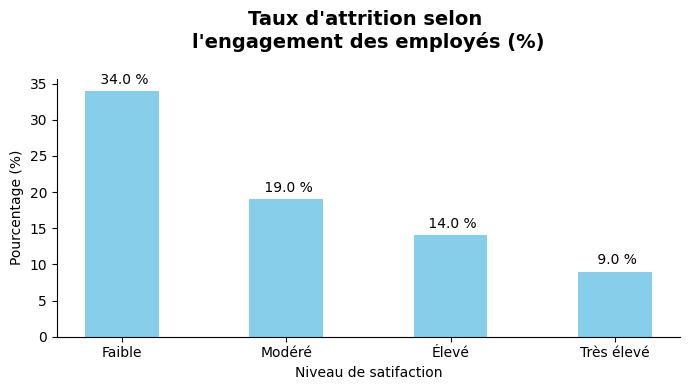

(None,)

In [26]:
pivot_jobInvolvement_attrition = pivot_jobInvolvement_attrition.sort_values("JobInvolvement_label", ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Données
x = np.arange(len(pivot_jobInvolvement_attrition.index))
y = pivot_jobInvolvement_attrition["Yes"]

# Barplot
bars = ax.bar(x, y, width=0.45, color="skyblue")

# Pourcentage affiché
ax.bar_label(bars, labels=[f"{v : .1F} %" for v in y], padding=3)

# Axes et labels
ax.set_xticks(x)
ax.set_xticklabels(pivot_jobInvolvement_attrition.index)

ax.set_xlabel("Niveau de satifaction")
ax.set_ylabel("Pourcentage (%)")
ax.set_title("Taux d'attrition selon \nl'engagement des employés (%)\n", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show(),

Ce graphique met en évidence que les salariés déclarant un niveau d’engagement **faible** présentent le taux d’attrition le plus élevé (≈ **34 %**).

À l’inverse, le taux d’attrition est le plus faible chez les salariés déclarant un niveau d’engagement **très élevé** (≈ 9 %).

Le taux moyen d’attrition diminue progressivement à mesure que le niveau d’engagement déclaré augmente.

#### 2.2.2.2 Attrition et l'évaluation du niveau de performance observée
---

##### Tableaux descriptifs (Proportion ­­(%) et Moyenne)

In [27]:
# Tableau de proportion
performanceRating_attrition = df_satisfaction_implication[["PerformanceRating_label", "Attrition"]]

pivot_performanceRating_attrition = pivot_percent(performanceRating_attrition,"PerformanceRating_label","Attrition")

# Tableau de moyenne
performanceRating_attrition_mean = groupby_mean(df_satisfaction_implication,"PerformanceRating","Attrition_num")

# Tableau côte à côte

display_html(
    """
    <div style="display: inline-flex; gap: 60px; align-items: flex-start;">
        <div>
            <h4>Tableau de proportions (%)</h4>
            {t1}
        </div>
        <div>
            <h4>Tableau de moyenne</h4>
            {t2}
        </div>
    </div>
    """.format(
            t1=pivot_performanceRating_attrition.to_html(),
            t2=performanceRating_attrition_mean.to_html()),
            raw=True)

Attrition,No,Yes
PerformanceRating_label,,
Excellente,84.0,16.0
Exceptionnelle,84.0,16.0
,PerformanceRating,Moyenne
0,3,0.16
1,4,0.16


On observe que le taux d’attrition est identique, autour de **16 %**, pour les deux niveaux de performance observés :**excellente** et **exceptionnelle**.

#### 2.3 Résultats clés – Satisfaction / Implication et attrition
---

Les analyses mettent en évidence plusieurs résultats marquants concernant la relation entre les niveaux d’engagement, de satisfaction et l’attrition.

- **Les taux d’attrition les plus élevés sont observés chez les salariés présentant les niveaux d’engagement les plus faibles.**  
  À l’inverse, le taux d’attrition diminue nettement à mesure que le niveau d’engagement augmente, traduisant une relation inverse claire entre ces deux variables.

- **Un schéma comparable est observé pour les différentes dimensions de la satisfaction au travail** (satisfaction vis-à-vis du poste, de l’environnement et des conditions de travail, ainsi que des relations professionnelles).  
  Les niveaux faibles de satisfaction sont associés à des taux d’attrition plus élevés, tandis que les niveaux de satisfaction plus élevés présentent des taux de départ plus faibles.  
  Cette décroissance, bien que non strictement linéaire, demeure nettement observable.

- Par ailleurs, **les salariés déclarant un équilibre vie professionnelle / vie personnelle insatisfaisant présentent les taux d’attrition les plus élevés.**  
  Le taux d’attrition diminue pour des niveaux d’équilibre jugés satisfaisants ou bons, avant de remonter légèrement pour le niveau d’équilibre déclaré excellent.

- **Enfin, le niveau de performance observé par l’entreprise présente des variations de taux d’attrition limitées**, sans différenciation nette entre les groupes analysés.



Une fois les comparaisons simples réalisées, j’explore les facteurs explicatif à l’axe afin d’identifier d’éventuels patterns ou corrélations.

## 3. Facteurs associés à la satisfaction et à l’implication
----

### 3.1 Introduction

Cette section ne vise pas à expliquer directement l’attrition, mais à identifier des facteurs associés aux niveaux de satisfaction et d’implication, susceptibles de jouer un rôle intermédiaire dans les mécanismes de départ observés précédemment.

Cette section vise à analyser les liens entre certaines variables organisationnelles et personnelles, et les niveaux de satisfaction et d’implication au travail.
L’objectif est d’identifier dans quelle mesure ces dimensions peuvent constituer des facteurs explicatifs intermédiaires dans la relation à l’attrition, analysée précédemment.


Les croisements sont réalisés par facteurs (organisationnelle/ personnelles), à partir des variables des niveaux de satisfaction et d'implication identifiées comme structurantes dans les axes précédents

Pour le niveau de satisfaction :
- jobsatisfaction et overtime oui
- jobsatisfaction et YearsWithCurrManager oui
- workbalance et distance  

Pour le niveau d'engagement :
- jobinvolvement et ancienneté dans le poste oui
- jobinvolvement et les heures suplémentaire
---
**Remarque moi**
Satisfaction × quelques variables clés de l’axe 2
Implication × quelques variables clés de l’axe 2
Éventuellement 1 variable perso

### 3.2 Analyse des variables organisationnelles et expérience collaborateur
---

Les variables sont analysées à partir de tableaux croisés (%) et de visualisations graphiques descriptives.

#### 3.2.1 Satisfaction au travail et variables organisationnelles
---
Cette sous-section analyse les liens entre certaines caractéristiques organisationnelles et les niveaux de satisfaction au travail, identifiés comme contributifs à l’attrition.

##### 3.2.1.1 Relation entre satisfaction vis à vis du poste et les heures supplementaires
---

##### Tableaux croisés (%)

##### Visualisation


***Observation descriptive***

##### 3.2.1.2 Relation entre satisfaction vis à vis du poste et la durée de collaboration avec le manager
---

#### 3.2.2 Implication au travail et variables organisationnelles
---
Cette sous-section explore la relation entre certaines variables organisationnelles et le niveau d’implication au travail, dans une logique comparable à celle appliquée à la satisfaction.

##### 3.2.2.1 Relation entre l'engagement et l'ancienneté dans le poste
---

##### Tableaux croisés (%)

##### Visualisation

***Observation descriptive***

##### 3.2.2.2 Relation entre l'engagement et les heures supplémentaires
---

### 3.3 Variables personnelles et expérience collaborateur
---
Les analyses précédentes ont mis en évidence des patterns structurants liés aux trajectoires de vie. Cette sous-section vise à explorer dans quelle mesure certaines caractéristiques individuelles peuvent être associées aux niveaux de satisfaction et d’implication.

Les variables sont analysées à partir de tableaux croisés (%) et de visualisations graphiques descriptives.

#### 3.3.1 Satisfaction / Implication et variables personnelles
---

##### 3.3.1.1 Relation entre l'équilibre vie professionnelle et personnelle et la distance domicile-travail
---            

##### Tableaux croisés (%)

##### Visualisation


***Observation descriptive***

Après avoir analysé ces relations, cette section synthétise les principaux patterns observés.

### 3.4 Synthèse des Patterns transversaux
---



# 4. Résultats clés 
---


---


# 5. Conclusion de l’axe “Condition de travail”
---
